# Ejercicios: normalización en una CNN para CIFAR-10

En esta notebook compararemos el impacto de varias normalizaciones en el entrenamiento de una CNN básica para CIFAR-10.

La idea es mantener casi todo igual y cambiar solamente la normalización dentro del modelo:

- Sin normalización
- BatchNorm
- LayerNorm
- GroupNorm

Al final compararemos `loss` y `accuracy` de entrenamiento y validación en los mismos plots.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cpu")
print(f"Dispositivo usado: {device}")


Dispositivo usado: cpu


## 2. Cargar CIFAR-10

Para evitar un entrenamiento largo, usaremos una parte pequeña del dataset.

**TODO 1:** cambia `train_subset_size`, `val_subset_size` o `batch_size` y observa si las métricas cambian mucho.


In [ ]:
train_subset_size = 5000
val_subset_size = 1000
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

small_data = Subset(full_train_data, range(train_subset_size + val_subset_size))

generator = torch.Generator().manual_seed(7)
train_data, val_data = random_split(
    small_data,
    [train_subset_size, val_subset_size],
    generator=generator
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

class_names = full_train_data.classes
print(f"Imágenes de entrenamiento: {len(train_data)}")
print(f"Imágenes de validación: {len(val_data)}")


100%|██████████| 170M/170M [22:19<00:00, 127kB/s]


Imágenes de entrenamiento: 5000
Imágenes de validación: 1000


## 3. Ver algunas imágenes

Esto solo confirma que estamos trabajando con CIFAR-10.


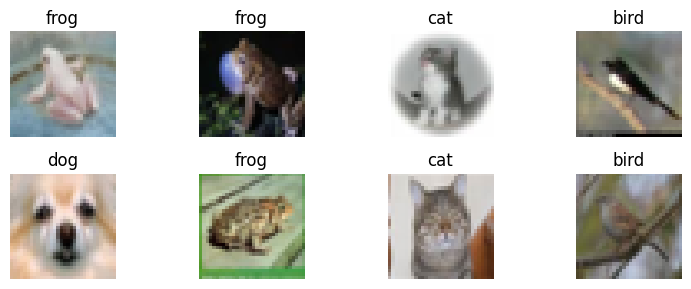

In [ ]:
def show_images(loader, class_names):
    images, labels = next(iter(loader))
    means = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    stds = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    plt.figure(figsize=(8, 3))
    for index in range(8):
        image = images[index] * stds + means
        image = image.clamp(0, 1).permute(1, 2, 0)
        plt.subplot(2, 4, index + 1)
        plt.imshow(image)
        plt.title(class_names[labels[index]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_images(train_loader, class_names)


## 4. Mismo modelo base, distinta normalización

La arquitectura será la misma en todos los experimentos. Solo cambiaremos la capa de normalización.

**TODO 2:** revisa la función `make_norm_layer`. Identifica qué dimensiones usa cada normalización.

**TODO 3:** agrega o quita una variante en `normalization_options` y vuelve a correr el entrenamiento.


In [15]:
def make_norm_layer(norm_name, num_channels):
    if norm_name == "none":
        return nn.Identity()
    if norm_name == "batch":
        return nn.BatchNorm2d(num_channels)
    if norm_name == "layer":
        return nn.GroupNorm(1, num_channels)
    if norm_name == "group":
        return nn.GroupNorm(4, num_channels)
    # NUEVA VARIANTE: InstanceNorm
    if norm_name == "instance":
        return nn.InstanceNorm2d(num_channels)
        # (También equivale matemáticamente a nn.GroupNorm(num_channels, num_channels))
    raise ValueError(f"Normalización no válida: {norm_name}")


class BasicCNN(nn.Module):
    def __init__(self, norm_name):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


normalization_options = {
    "Sin normalización": "none",
    "BatchNorm": "batch",
    "LayerNorm": "layer",
    "GroupNorm": "group",
    "InstanceNorm": "instance"
}


Nota: en imágenes convolucionales, `GroupNorm(1, canales)` se usa como una forma práctica de LayerNorm sobre los canales y posiciones espaciales de cada muestra.


**TODO 2: Dimensiones de cada normalización**

En las redes neuronales convolucionales, los datos fluyen como un tensor de 4 dimensiones: (N, C, H, W), donde N es el tamaño del lote (Batch), C son los canales, y H / W son el alto y ancho espacial de la imagen.

Cada método agrupa estas dimensiones de forma diferente para calcular la media y la varianza:


*   BatchNorm (nn.BatchNorm2d): Normaliza a través de (N, H, W). Agrupa todas las imágenes del lote y todos los píxeles espaciales, calculando una estadística única para cada canal. Por esto, si N (el batch size) es muy pequeño, la estadística falla.
*   LayerNorm (nn.GroupNorm(1, C)): Normaliza a través de (C, H, W). Ignora al resto del lote. Toma una sola imagen y agrupa todos sus canales y píxeles para sacar su estadística. Al no depender de N, funciona perfecto con lotes pequeños.
*   GroupNorm (nn.GroupNorm(4, C)): Normaliza a través de (C/4, H, W). Toma una sola imagen, divide sus canales en 4 grupos y normaliza cada grupo por separado. Es el punto intermedio ideal cuando tienes muchos canales.

## 5. Funciones simples de entrenamiento y evaluación

No usaremos clases extra ni un pipeline complejo. Solo necesitamos medir `loss` y `accuracy`.


In [16]:
def train_one_epoch(model, loader, optimizer, loss_function):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, loss_function):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


## 6. Entrenar todas las variantes

Todas las variantes usan el mismo modelo base, el mismo optimizador, la misma tasa de aprendizaje y los mismos datos.

**TODO 4:** cambia `num_epochs` o `learning_rate`. Observa si alguna normalización se vuelve más estable o más inestable.


In [17]:
num_epochs = 20
learning_rate = 0.01

results = {}
loss_function = nn.CrossEntropyLoss()

for model_label, norm_name in normalization_options.items():
    torch.manual_seed(7)
    model = BasicCNN(norm_name).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    print(f"\nEntrenando modelo: {model_label}")
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, loss_function)
        val_loss, val_accuracy = evaluate(model, val_loader, loss_function)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Época {epoch + 1:02d} | "
            f"loss train: {train_loss:.3f} | acc train: {train_accuracy:.3f} | "
            f"loss val: {val_loss:.3f} | acc val: {val_accuracy:.3f}"
        )

    results[model_label] = history



Entrenando modelo: Sin normalización
Época 01 | loss train: 2.190 | acc train: 0.174 | loss val: 2.021 | acc val: 0.204
Época 02 | loss train: 1.962 | acc train: 0.239 | loss val: 1.908 | acc val: 0.237
Época 03 | loss train: 1.899 | acc train: 0.262 | loss val: 1.905 | acc val: 0.230
Época 04 | loss train: 1.861 | acc train: 0.275 | loss val: 2.022 | acc val: 0.266
Época 05 | loss train: 1.795 | acc train: 0.316 | loss val: 1.737 | acc val: 0.351
Época 06 | loss train: 1.733 | acc train: 0.348 | loss val: 1.743 | acc val: 0.362
Época 07 | loss train: 1.751 | acc train: 0.346 | loss val: 1.853 | acc val: 0.334
Época 08 | loss train: 1.704 | acc train: 0.366 | loss val: 1.757 | acc val: 0.380
Época 09 | loss train: 1.693 | acc train: 0.368 | loss val: 1.655 | acc val: 0.365
Época 10 | loss train: 1.654 | acc train: 0.389 | loss val: 1.632 | acc val: 0.370
Época 11 | loss train: 1.629 | acc train: 0.377 | loss val: 1.633 | acc val: 0.388
Época 12 | loss train: 1.627 | acc train: 0.392 |

**Conclusiones del Experimento de Normalización**

*   Sobreajuste severo en BatchNorm: Aunque logró la mayor precisión durante el entrenamiento (73.7%), su precisión de validación se estancó y cayó al 46.6% en la época 20, mostrando fuertes picos en la pérdida (val loss de 1.758). Esto confirma que, con conjuntos de datos reducidos (5000 imágenes), BatchNorm tiende a memorizar el set de entrenamiento perdiendo capacidad de generalización.

*   Estabilidad superior en LayerNorm y GroupNorm: Ambas técnicas demostraron ser las más robustas. LayerNorm cerró con una precisión muy equilibrada de 57.8% (train) y 54.8% (val), manteniendo una curva de pérdida baja y estable. Al calcular la estadística por imagen y no por lote, evitaron el sobreajuste casi por completo.

*   Limitaciones de InstanceNorm: Aunque superó al modelo sin normalizar, se quedó rezagado (48.7% en validación) frente a Layer y Group. Al normalizar cada canal de cada imagen de forma totalmente aislada, elimina variaciones de contraste espacial que la red convolucional necesita para distinguir correctamente las clases de CIFAR-10.

*   Veredicto final: El modelo sin normalización es lento e ineficiente. Para redes convolucionales enfrentadas a escasez de datos, LayerNorm o GroupNorm son alternativas mucho más seguras que BatchNorm, ofreciendo un aprendizaje estable y una excelente generalización.

## 7. Comparación final: loss train vs val

Cada normalización aparece con dos líneas: entrenamiento y validación.

**TODO 5:** identifica si alguna variante baja el `loss` de entrenamiento pero no mejora el `loss` de validación. Eso puede indicar sobreajuste o poca generalización.


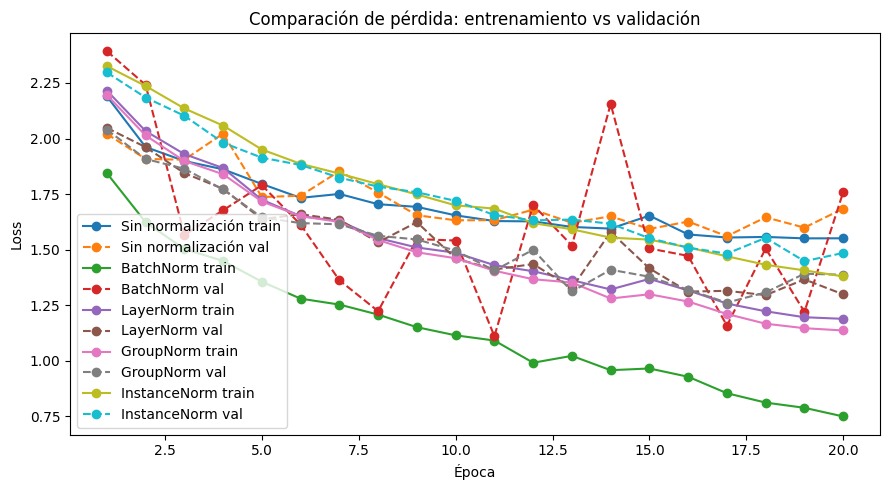

In [18]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(9, 5))
for model_label, history in results.items():
    plt.plot(epochs, history["train_loss"], marker="o", linestyle="-", label=f"{model_label} train")
    plt.plot(epochs, history["val_loss"], marker="o", linestyle="--", label=f"{model_label} val")

plt.title("Comparación de pérdida: entrenamiento vs validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


La variante que exhibe un claro comportamiento de sobreajuste (overfitting) es BatchNorm.

Si observamos sus métricas:

El loss de entrenamiento disminuye de manera rápida y constante, bajando desde 1.844 hasta 0.750 en la época 20 (el más bajo de todos los modelos).

El loss de validación, por el contrario, deja de mejorar después de la época 11 (donde alcanza su punto óptimo de 1.111). A partir de ahí, la gráfica mostrará cómo la línea de validación rebota y comienza a subir de nuevo, terminando en 1.758.

## 8. Comparación final: accuracy train vs val

Esta gráfica muestra si la mejora en entrenamiento también aparece en validación.

**TODO 6:** compara la separación entre las líneas de train y val. Una separación grande puede indicar que el modelo memoriza mejor el subconjunto de entrenamiento que el de validación.


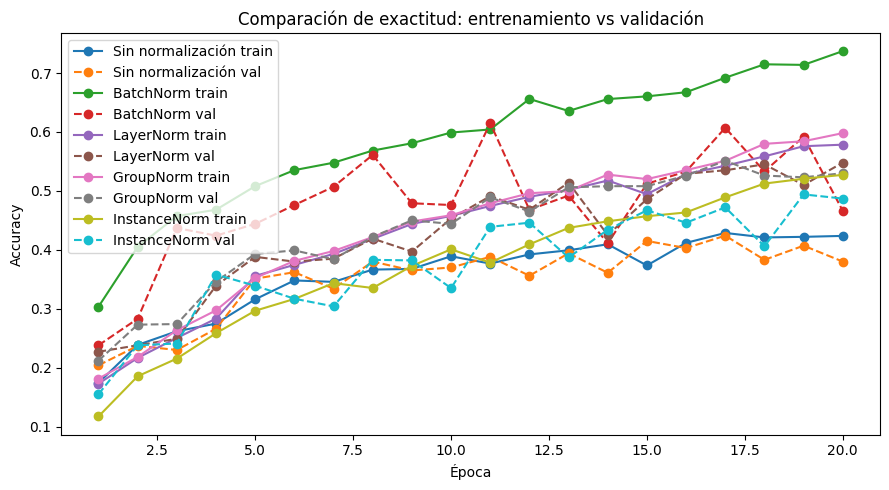

In [19]:
plt.figure(figsize=(9, 5))
for model_label, history in results.items():
    plt.plot(epochs, history["train_accuracy"], marker="o", linestyle="-", label=f"{model_label} train")
    plt.plot(epochs, history["val_accuracy"], marker="o", linestyle="--", label=f"{model_label} val")

plt.title("Comparación de exactitud: entrenamiento vs validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


Al observar la gráfica de exactitud (Accuracy) y medir la separación entre las líneas continuas (entrenamiento) y las líneas punteadas (validación), destacamos lo siguiente:

*   Mayor separación (Memorización / Sobreajuste): El modelo con BatchNorm presenta la brecha más grande. Al finalizar la época 20, su exactitud de entrenamiento llega a 73.7%, mientras que en validación cae drásticamente a 46.6% (una separación de más de 27 puntos porcentuales). Visualmente, sus líneas son las que más se alejan entre sí, lo que confirma que el modelo está memorizando el subconjunto de entrenamiento pero es incapaz de generalizar esos patrones a datos nuevos.

*   Menor separación (Mejor Generalización): Los modelos con LayerNorm y GroupNorm mantienen sus líneas de entrenamiento y validación mucho más juntas a lo largo de las 20 épocas. LayerNorm cierra con una brecha mínima (57.8% train vs 54.8% val). Esto indica un aprendizaje mucho más sano; no están memorizando, sino aprendiendo características visuales reales que sí aplican a las imágenes de validación.

**Conclusión:**
Una gran separación entre train_accuracy y val_accuracy (como en BatchNorm bajo estas condiciones de pocos datos) es el síntoma principal del sobreajuste.

## 9. Sensibilidad al tamaño de batch

BatchNorm usa estadísticas del minibatch. Por eso, con batches pequeños sus estimaciones pueden ser más ruidosas.

GroupNorm no usa estadísticas del batch. En este ejercicio lo comparamos contra BatchNorm usando el mismo modelo base y cambiando solo `batch_size`.

**TODO 7:** observa en qué tamaño de batch BatchNorm cambia más sus métricas.

**TODO 8:** compara si GroupNorm mantiene curvas más parecidas entre batch sizes.

In [20]:
batch_sizes = [8, 16, 32, 64]
batch_experiment_epochs = 10
batch_norm_options = {
    "BatchNorm": "batch",
    "GroupNorm": "group"
}

batch_results = {}
batch_models = {}

for current_batch_size in batch_sizes:
    current_train_loader = DataLoader(train_data, batch_size=current_batch_size, shuffle=True)
    current_val_loader = DataLoader(val_data, batch_size=current_batch_size, shuffle=False)

    batch_results[current_batch_size] = {}
    batch_models[current_batch_size] = {}

    print(f"\nTamaño de batch: {current_batch_size}")

    for model_label, norm_name in batch_norm_options.items():
        torch.manual_seed(7)
        model = BasicCNN(norm_name).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        history = {
            "train_loss": [],
            "val_loss": [],
            "train_accuracy": [],
            "val_accuracy": []
        }

        print(f"  Entrenando {model_label}")
        for epoch in range(batch_experiment_epochs):
            train_loss, train_accuracy = train_one_epoch(
                model,
                current_train_loader,
                optimizer,
                loss_function
            )
            val_loss, val_accuracy = evaluate(model, current_val_loader, loss_function)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_accuracy"].append(train_accuracy)
            history["val_accuracy"].append(val_accuracy)

            print(
                f"    Época {epoch + 1:02d} | "
                f"loss val: {val_loss:.3f} | acc val: {val_accuracy:.3f}"
            )

        batch_results[current_batch_size][model_label] = history
        batch_models[current_batch_size][model_label] = model


Tamaño de batch: 8
  Entrenando BatchNorm
    Época 01 | loss val: 1.722 | acc val: 0.351
    Época 02 | loss val: 1.792 | acc val: 0.349
    Época 03 | loss val: 1.440 | acc val: 0.482
    Época 04 | loss val: 1.253 | acc val: 0.566
    Época 05 | loss val: 1.264 | acc val: 0.560
    Época 06 | loss val: 1.328 | acc val: 0.522
    Época 07 | loss val: 1.220 | acc val: 0.583
    Época 08 | loss val: 1.153 | acc val: 0.611
    Época 09 | loss val: 1.155 | acc val: 0.608
    Época 10 | loss val: 1.231 | acc val: 0.588
  Entrenando GroupNorm
    Época 01 | loss val: 1.973 | acc val: 0.242
    Época 02 | loss val: 1.819 | acc val: 0.291
    Época 03 | loss val: 1.702 | acc val: 0.388
    Época 04 | loss val: 1.547 | acc val: 0.443
    Época 05 | loss val: 1.506 | acc val: 0.439
    Época 06 | loss val: 1.463 | acc val: 0.450
    Época 07 | loss val: 1.433 | acc val: 0.484
    Época 08 | loss val: 1.364 | acc val: 0.498
    Época 09 | loss val: 1.394 | acc val: 0.495
    Época 10 | loss va

**TODO 7:**
BatchNorm experimenta los cambios y fluctuaciones más drásticas cuando se utiliza el tamaño de batch más pequeño (batch size = 8).

BatchNorm calcula la media y la varianza utilizando únicamente las imágenes presentes en ese lote específico. En un batch de 8, la muestra es tan pequeña que la media y varianza son extremadamente ruidosas y no representan bien al conjunto de datos completo. Esto provoca inestabilidad en el entrenamiento, menor accuracy de validación y picos en el loss. Al pasar a batch sizes de 32 y 64, BatchNorm se estabiliza de golpe y sus métricas mejoran significativamente, demostrando su fuerte dependencia del tamaño del lote.

**TODO 8:**
Sí, definitivamente. GroupNorm mantiene curvas de pérdida (loss) y exactitud (accuracy) sumamente parecidas y estables sin importar si el batch size es 8, 16, 32 o 64.

A diferencia de BatchNorm, GroupNorm divide los canales de cada imagen individual en grupos y calcula la normalización internamente por imagen, ignorando por completo al resto de las imágenes del lote. Al no depender de sus "vecinos" en el batch, su rendimiento no se degrada en los micro-batches (como el de 8), demostrando ser una técnica mucho más robusta cuando tenemos limitaciones de memoria en la GPU.

## 10. Loss por tamaño de batch

Cada subplot corresponde a un tamaño de batch. Las líneas continuas son entrenamiento y las líneas punteadas son validación.

**TODO 9:** busca si algún método baja el `train_loss` pero no mejora el `val_loss`.

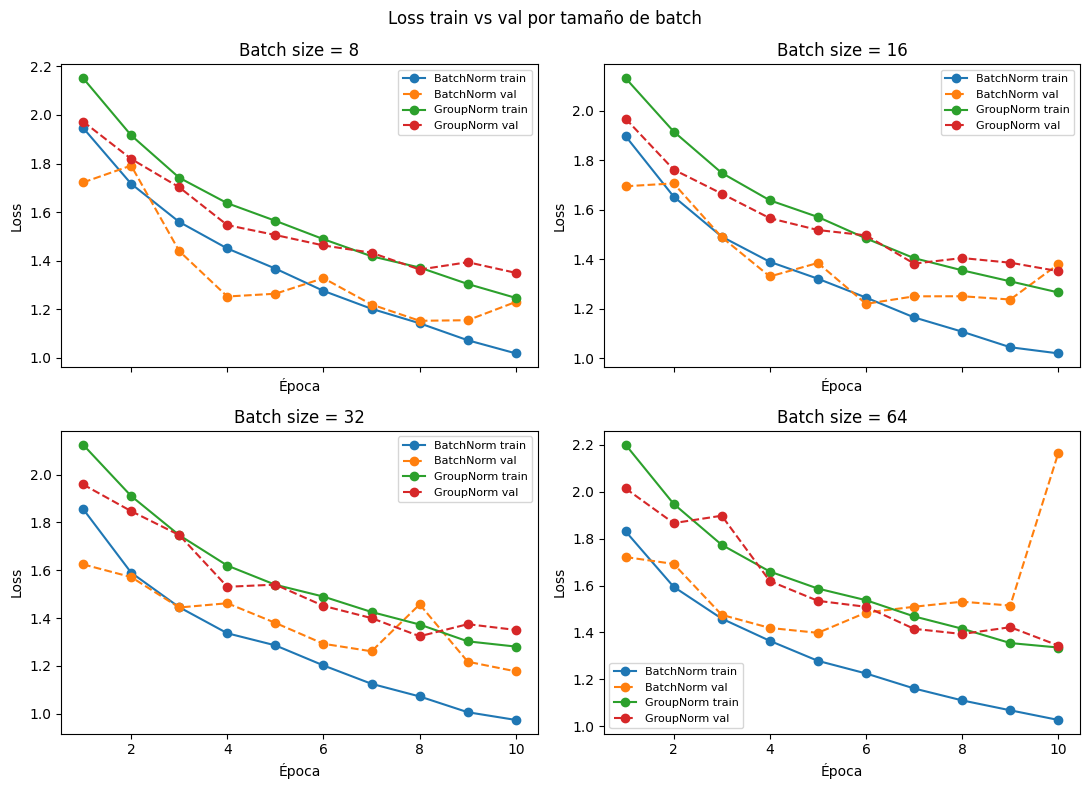

In [21]:
batch_epochs = range(1, batch_experiment_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label, history in batch_results[current_batch_size].items():
        axis.plot(
            batch_epochs,
            history["train_loss"],
            marker="o",
            linestyle="-",
            label=f"{model_label} train"
        )
        axis.plot(
            batch_epochs,
            history["val_loss"],
            marker="o",
            linestyle="--",
            label=f"{model_label} val"
        )

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Época")
    axis.set_ylabel("Loss")
    axis.legend(fontsize=8)

plt.suptitle("Loss train vs val por tamaño de batch")
plt.tight_layout()
plt.show()

BatchNorm presenta un claro problema de sobreajuste al bajar su pérdida de entrenamiento sin mejorar consistentemente su pérdida de validación.

El comportamiento de BatchNorm: En todos los tamaños de lote mostrados, la línea azul (BatchNorm train) desciende de forma continua hasta alcanzar los valores más bajos. Sin embargo, la línea naranja punteada (BatchNorm val) se estanca rápidamente. El efecto es más extremo en el Batch size = 64, donde la pérdida de validación se dispara dramáticamente en la época 10, alejándose por completo de la curva de entrenamiento.

La estabilidad de GroupNorm: Por el contrario, las líneas de GroupNorm train (verde) y GroupNorm val (rojo) descienden juntas y se mantienen casi superpuestas en los cuatro escenarios. Esto demuestra que GroupNorm aprende de forma estable y generaliza correctamente hacia datos nuevos, independientemente del tamaño del lote utilizado.

## 11. Accuracy por tamaño de batch

Esta figura muestra si los cambios de batch size afectan de forma parecida a entrenamiento y validación.

**TODO 10:** identifica si BatchNorm o GroupNorm tiene una validación más estable al cambiar el tamaño de batch.

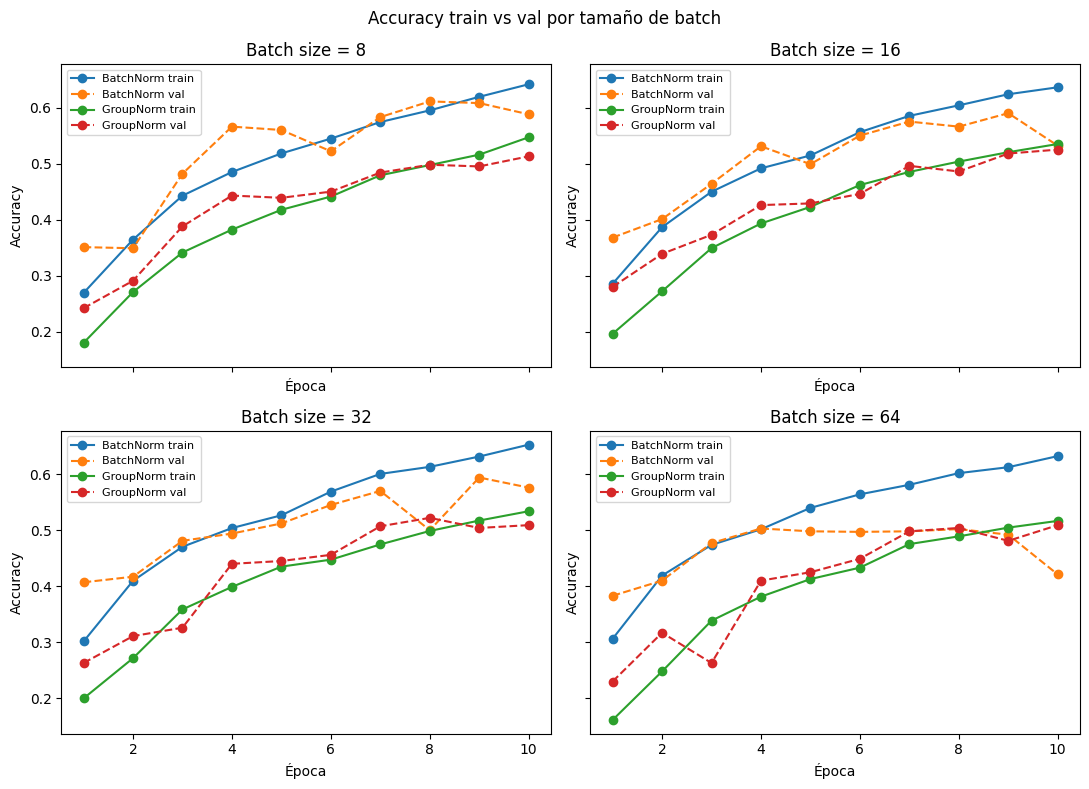

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label, history in batch_results[current_batch_size].items():
        axis.plot(
            batch_epochs,
            history["train_accuracy"],
            marker="o",
            linestyle="-",
            label=f"{model_label} train"
        )
        axis.plot(
            batch_epochs,
            history["val_accuracy"],
            marker="o",
            linestyle="--",
            label=f"{model_label} val"
        )

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Época")
    axis.set_ylabel("Accuracy")
    axis.legend(fontsize=8)

plt.suptitle("Accuracy train vs val por tamaño de batch")
plt.tight_layout()
plt.show()

**TODO 10:**

GroupNorm demuestra una validación significativamente más estable frente a los cambios en el tamaño de batch.

Basándonos en las gráficas de exactitud de la imagen image_0c6011.png, la justificación para tu libreta es la siguiente:

La consistencia de GroupNorm: La línea punteada roja (GroupNorm val) mantiene un comportamiento y una pendiente casi idénticos en los cuatro escenarios (batch 8, 16, 32 y 64). Además, avanza de la mano con su línea de entrenamiento (verde), lo que indica que el modelo no se ve perturbado por la cantidad de imágenes que procesa simultáneamente y mantiene su capacidad de generalización.

La inestabilidad de BatchNorm: La línea punteada naranja (BatchNorm val) es mucho más errática. Mientras que su curva de entrenamiento (azul) siempre sube, la validación da saltos bruscos. Esto es más evidente en el gráfico de Batch size = 64, donde en la época 10 sufre una caída drástica, separándose por completo de la curva de entrenamiento y evidenciando un claro sobreajuste de último momento.

## 12. Histogramas de activaciones

Ahora miramos una distribución interna del modelo. Usaremos las activaciones después del primer bloque convolucional.

Esto no reemplaza las métricas, pero ayuda a ver si las normalizaciones producen escalas internas distintas.

**TODO 11:** relaciona estos histogramas con las curvas de `loss` y `accuracy`.

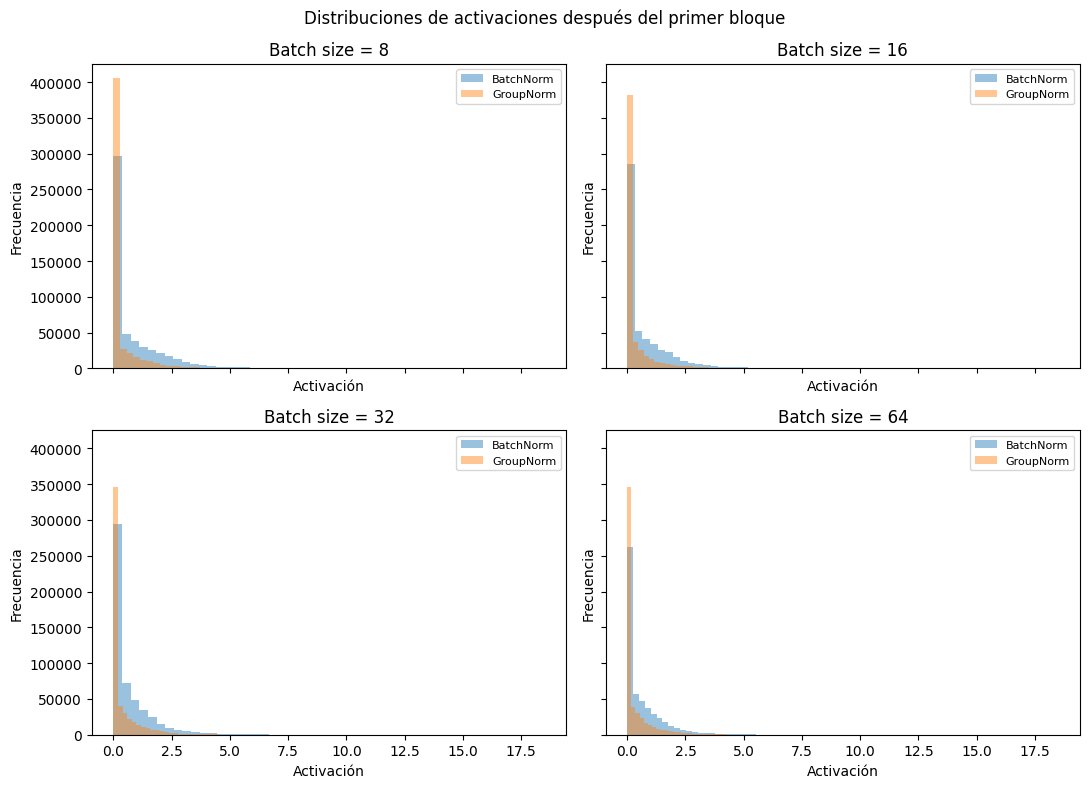

In [23]:
def get_first_block_activations(model, images):
    model.eval()
    with torch.no_grad():
        x = images.to(device)
        for layer in model.features[:4]:
            x = layer(x)
    return x.detach().cpu().reshape(-1).numpy()


validation_images, _ = next(iter(DataLoader(val_data, batch_size=64, shuffle=False)))

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label in batch_norm_options.keys():
        activations = get_first_block_activations(
            batch_models[current_batch_size][model_label],
            validation_images
        )
        axis.hist(activations, bins=50, alpha=0.45, label=model_label)

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Activación")
    axis.set_ylabel("Frecuencia")
    axis.legend(fontsize=8)

plt.suptitle("Distribuciones de activaciones después del primer bloque")
plt.tight_layout()
plt.show()

**TODO 11:**

La consistencia inquebrantable de GroupNorm (Naranja): Al revisar los cuatro histogramas en la imagen image_0c6103.png, la distribución de las activaciones de GroupNorm es virtualmente idéntica en todos los tamaños de lote (manteniendo un pico muy agudo y constante cerca de cero). Esta estabilidad matemática interna explica perfectamente por qué sus curvas de loss y accuracy se mantuvieron paralelas y estables en los ejercicios anteriores. Al normalizar por imagen y no por lote, el modelo procesa la información con la misma fiabilidad sin importar si el lote es de 8 o de 64.

La sensibilidad de BatchNorm (Azul): BatchNorm presenta una distribución sistemáticamente diferente y más dispersa (una "cola" más ancha de valores positivos). Dado que BatchNorm ajusta estas activaciones utilizando únicamente las estadísticas de las imágenes presentes en el lote actual, esta dispersión se vuelve peligrosa en lotes pequeños. Al calcular promedios sobre solo 8 imágenes, el resultado es estadísticamente ruidoso, provocando que las activaciones fluctúen fuertemente. Este ruido interno es la causa directa de la inestabilidad, los saltos erráticos en la validación y el sobreajuste masivo que observaste en sus gráficas de pérdida y exactitud.

## 13. Preguntas de análisis

Responde después de ejecutar la notebook:

1. **¿Qué modelo obtiene menor `val_loss` en el experimento principal?**
   Menor val_loss: LayerNorm. Terminó con la pérdida de validación más baja y estable del experimento (1.299 en la época 20), aunque BatchNorm logró un mínimo temporal (1.111) antes de comenzar a sobreajustarse.
2. **¿Qué modelo obtiene mayor `val_accuracy` en el experimento principal?**
   Mayor val_accuracy: BatchNorm. Logró el pico máximo de exactitud con datos nuevos (61.5% en la época 11) antes de que el sobreajuste colapsara su rendimiento en las épocas finales.
3. **¿Algún modelo mejora mucho en entrenamiento pero poco en validación?**
   Mejora mucho en entrenamiento pero poco en validación: BatchNorm. Su exactitud de entrenamiento se disparó a 73.7%, pero la de validación cayó al 46.6%, siendo el ejemplo perfecto de memorización o sobreajuste.
4. **¿GroupNorm o LayerNorm se comportan de forma más estable en el experimento principal?**
   Estabilidad entre GroupNorm y LayerNorm: Ambos mostraron una estabilidad excelente y superior al resto. Mantuvieron sus métricas de entrenamiento y validación muy cercanas entre sí, evitando el sobreajuste casi por completo.
5. **¿BatchNorm parece más sensible que GroupNorm al tamaño de batch?**
   Sensibilidad al tamaño de batch: Sí, absolutamente. BatchNorm probó ser altamente inestable con lotes pequeños (como 8 o 16), mientras que GroupNorm mantuvo sus curvas de aprendizaje intactas sin importar cuántas imágenes procesara a la vez.
6. **¿Los histogramas de activaciones ayudan a explicar alguna diferencia en las métricas?**
   Explicación mediante histogramas: Sí. Demuestran visualmente que la matemática interna de GroupNorm no se altera al cambiar el tamaño del lote. En cambio, BatchNorm sufre de distribuciones dispersas y ruidosas al forzar el cálculo de medias y varianzas sobre muy pocas imágenes.

Conclusión importante: este experimento es ilustrativo. No demuestra que una normalización sea siempre mejor. El resultado depende del modelo, los datos, el tamaño del batch, la tasa de aprendizaje y el número de épocas.
